In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
DATA_DIR = Path("../data/splits")
MODEL_DIR = Path("../models")
OUTPUT_DIR = Path("../outputs")

TEST_FILE = DATA_DIR / "test.parquet"

In [3]:
test_df = pd.read_parquet(TEST_FILE)

test_df.head()

,text,generated,text_length
0,"Dear principal TEACHER_NAME,\n\nI have heard t...",0,1582
1,This is not valuable to have in a classroom wi...,0,1235
2,"In my personal opinion, I think that it would ...",0,990
3,Facial Action Coding System (FACS) is a unique...,1,2904
4,Have even seen the cowboys on TV and wanted to...,0,1576


In [4]:
print(test_df.shape)
print(test_df.columns)

(73083, 3)
Index(['text', 'generated', 'text_length'], dtype='object')


In [5]:
log_reg = joblib.load(
    MODEL_DIR / "tfidf_logistic_regression_model.joblib"
)

log_tfidf = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

svm_model = joblib.load(
    MODEL_DIR / "tfidf_svm_model.joblib"
)

svm_tfidf = joblib.load(
    MODEL_DIR / "tfidf_svm_vectorizer.joblib"
)

print("Models loaded successfully.")

Models loaded successfully.


In [6]:
test_df["text_length"] = test_df["text"].str.len()

test_df["text_length"].describe()

count    73083.000000
mean      2267.269652
std        985.329074
min         81.000000
25%       1582.000000
50%       2101.000000
75%       2724.000000
max       9157.000000
Name: text_length, dtype: float64

In [7]:
test_df["length_group"] = pd.qcut(
    test_df["text_length"],
    q=5,
    labels=[
        "Very Short",
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

test_df["length_group"].value_counts()

length_group
Very Short    14636
Medium        14620
Very Long     14613
Long          14612
Short         14602
Name: count, dtype: int64

In [8]:
X_test_log = log_tfidf.transform(test_df["text"])

test_df["logistic_pred"] = log_reg.predict(X_test_log)

In [9]:
X_test_svm = svm_tfidf.transform(test_df["text"])

test_df["svm_pred"] = svm_model.predict(X_test_svm)

In [10]:
def calculate_group_metrics(df, prediction_column):
    rows = []

    for group, subset in df.groupby("length_group", observed=False):
        y_true = subset["generated"]
        y_pred = subset[prediction_column]

        rows.append({
            "length_group": group,
            "samples": len(subset),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        })

    return pd.DataFrame(rows)

In [11]:
logistic_length_results = calculate_group_metrics(
    test_df,
    "logistic_pred"
)

logistic_length_results

,length_group,samples,accuracy,precision,recall,f1
0,Very Short,14636,0.992348,0.989814,0.985450,0.987627
1,Short,14602,0.995001,0.995309,0.993290,0.994298
2,Medium,14620,0.994186,0.995278,0.992579,0.993926
3,Long,14612,0.997468,0.996966,0.996798,0.996882
4,Very Long,14613,0.995962,0.983723,0.998798,0.991203


In [12]:
svm_length_results = calculate_group_metrics(
    test_df,
    "svm_pred"
)

svm_length_results

,length_group,samples,accuracy,precision,recall,f1
0,Very Short,14636,0.999043,0.998677,0.998236,0.998456
1,Short,14602,0.999452,0.999220,0.999532,0.999376
2,Medium,14620,0.998700,0.999143,0.998145,0.998644
3,Long,14612,0.999795,0.999495,1.000000,0.999747
4,Very Long,14613,0.999863,0.999399,1.000000,0.999700


In [13]:
comparison_length = logistic_length_results[
    ["length_group", "f1"]
].rename(
    columns={"f1": "Logistic Regression"}
)

comparison_length["SVM"] = svm_length_results["f1"]

comparison_length

,length_group,Logistic Regression,SVM
0,Very Short,0.987627,0.998456
1,Short,0.994298,0.999376
2,Medium,0.993926,0.998644
3,Long,0.996882,0.999747
4,Very Long,0.991203,0.999700


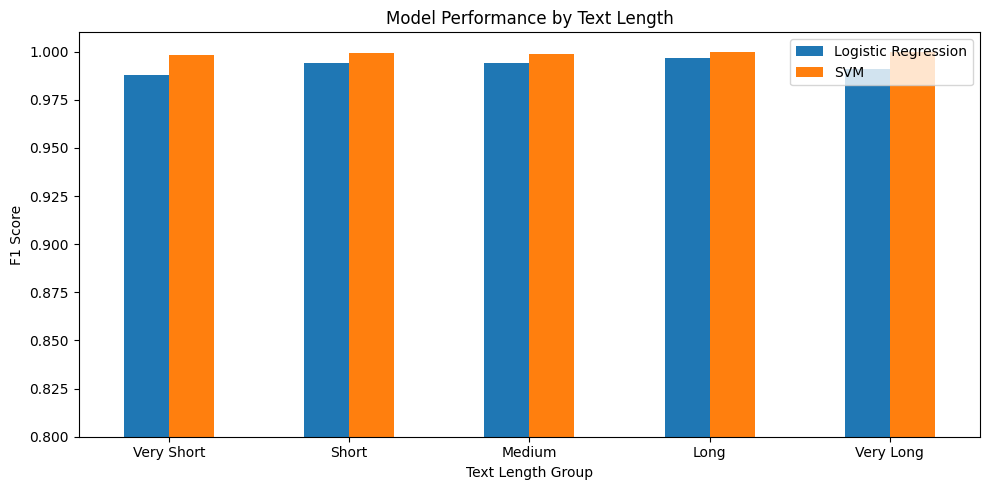

In [14]:
comparison_length.set_index("length_group").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("F1 Score")
plt.xlabel("Text Length Group")
plt.title("Model Performance by Text Length")
plt.ylim(0.8, 1.01)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
logistic_errors = test_df[
    test_df["generated"] != test_df["logistic_pred"]
].copy()

print("Logistic Regression errors:", len(logistic_errors))

logistic_errors.head()

Logistic Regression errors: 366


,text,generated,text_length,length_group,logistic_pred,svm_pred
142,"Sure, here's my Attempt Kt writing Kn essay Ks...",1,1939,Medium,0,1
311,I think that student should have the rate to g...,1,2026,Medium,0,1
600,"It was the summer of '42, and I was a teenager...",1,1583,Short,0,1
685,People who value self-reliance define it as th...,0,3059,Very Long,1,0
693,Thy most effective way to influence others is ...,1,2478,Long,0,1


In [16]:
svm_errors = test_df[
    test_df["generated"] != test_df["svm_pred"]
].copy()

print("SVM errors:", len(svm_errors))

svm_errors.head()

SVM errors: 46


,text,generated,text_length,length_group,logistic_pred,svm_pred
283,"Some people be asking when someone ask them ""w...",0,2144,Medium,0,1
2214,Should some people believe in praising a stude...,1,2240,Medium,0,0
3430,Have you ever thought of a place in the world ...,0,1305,Very Short,1,1
3460,Are driverless car really the future of transp...,1,1797,Short,0,0
3935,"When people ark for advice, they should talk t...",1,1255,Very Short,0,0


In [17]:
logistic_fp = logistic_errors[
    (logistic_errors["generated"] == 0) &
    (logistic_errors["logistic_pred"] == 1)
]

logistic_fn = logistic_errors[
    (logistic_errors["generated"] == 1) &
    (logistic_errors["logistic_pred"] == 0)
]

print("Logistic false positives:", len(logistic_fp))
print("Logistic false negatives:", len(logistic_fn))

Logistic false positives: 182
Logistic false negatives: 184


In [18]:
svm_fp = svm_errors[
    (svm_errors["generated"] == 0) &
    (svm_errors["svm_pred"] == 1)
]

svm_fn = svm_errors[
    (svm_errors["generated"] == 1) &
    (svm_errors["svm_pred"] == 0)
]

print("SVM false positives:", len(svm_fp))
print("SVM false negatives:", len(svm_fn))

SVM false positives: 22
SVM false negatives: 24


In [20]:
error_summary = []

for group, subset in test_df.groupby("length_group", observed=False):

    logistic_error_rate = (
        subset["generated"] != subset["logistic_pred"]
    ).mean()

    svm_error_rate = (
        subset["generated"] != subset["svm_pred"]
    ).mean()

    error_summary.append({
        "length_group": group,
        "samples": len(subset),
        "logistic_error_rate": logistic_error_rate,
        "svm_error_rate": svm_error_rate
    })

error_summary_df = pd.DataFrame(error_summary)

error_summary_df

,length_group,samples,logistic_error_rate,svm_error_rate
0,Very Short,14636,0.007652,0.000957
1,Short,14602,0.004999,0.000548
2,Medium,14620,0.005814,0.001300
3,Long,14612,0.002532,0.000205
4,Very Long,14613,0.004038,0.000137


In [21]:
test_df["logistic_wrong"] = (
    test_df["generated"] != test_df["logistic_pred"]
)

test_df["svm_wrong"] = (
    test_df["generated"] != test_df["svm_pred"]
)

both_wrong = test_df[
    test_df["logistic_wrong"] &
    test_df["svm_wrong"]
]

logistic_only_wrong = test_df[
    test_df["logistic_wrong"] &
    ~test_df["svm_wrong"]
]

svm_only_wrong = test_df[
    ~test_df["logistic_wrong"] &
    test_df["svm_wrong"]
]

print("Wrong by both:", len(both_wrong))
print("Wrong only by Logistic:", len(logistic_only_wrong))
print("Wrong only by SVM:", len(svm_only_wrong))

Wrong by both: 39
Wrong only by Logistic: 327
Wrong only by SVM: 7


In [22]:
pd.set_option("display.max_colwidth", 300)

both_wrong[
    [
        "text",
        "generated",
        "logistic_pred",
        "svm_pred",
        "text_length",
        "length_group"
    ]
].head(10)

,text,generated,logistic_pred,svm_pred,text_length,length_group
2214,"Should some people believe in praising a student's work to build self-esteem, even if the work is not the student's best effort? They believe that students must be self-confident in order to learn. I agree with students must be self-confident because it's better to grow in life then stay in the ...",1,0,0,2240,Medium
3430,"Have you ever thought of a place in the world you would like to visit? Some people would go to France to see the popular Eiffel Tower; while others would go to Hawaii just to relax. For me however, I would like to visit Generic_City because the people there are well-mannered and kind. And also b...",0,1,1,1305,Very Short
3460,"Are driverless car really the future of transportation? I think they’re a terrible idea.\n\nSure, some people might gay that driverless car will reduce accident, since computer don’t get distracted or sleepy like human do. And the author of the article “Driverless Car are Coming” gang that “90 p...",1,0,0,1797,Short
3935,"When people ark for advice, they should talk to more than one person because it can help them make a better choice. If someone only talk to one person, they might get a board opinion and Mir out on other option. By reeking multiple opinion, they can get different perspective and consider more po...",1,0,0,1255,Very Short
4636,"Hi, I'm a 6th grader, and I'm going to write an eBay about if students should have the right to grade their teacher.\n\nI think that students should have the right to grade their teacher. First of all, it'b important for teacher to know how they're doing and if they're helping their students lea...",1,0,0,2165,Medium
5589,"Have you ever made a really bad mistake and think you can never come back from it? You can always come back from a mistake. Duke Elligton the famous jazz legend always said ""a problem is a chance to do your best because you learn from your mistakes.\n\nIf you mess up and make a mistake you will ...",0,1,1,1786,Short
6919,"Imagine walking outside with your dog and someone comes up ZO and Areas you like a criminal like he just killed a person, sole money, and bombed a house! Would you like ZO be Created like a criminal for The rest of your life with nobody Talking ZO you or respecting you? 62% of The people around ...",1,0,0,2063,Medium
7933,I don't believe school should follow in businesses footsteps and do the four-day school week. I believe that school should stick with the five-day school week. Because it would be better for the students in the long run.\n\nIf school keep the five-day school week there would be a lot of benefits...,0,1,1,1539,Short
7944,the memorable teacher ever had\r\n\r\nwas a teacher in 10\r\n\r\nword\r\n\r\nwild all students,0,1,1,82,Very Short
8761,"The Development of Driverless Car\n\nThe advancement of driverless vehicle technology bring both opportunities and challenge. While autonomous vehicle could Significantly reduce accident and increase mobility, fully replacing human driver also present Serious Rikki that must be addressed. A bala...",1,0,0,2056,Medium


In [23]:
error_overlap_df = pd.DataFrame({
    "Category": [
        "Wrong by both models",
        "Wrong only by Logistic Regression",
        "Wrong only by SVM"
    ],
    "Count": [
        len(both_wrong),
        len(logistic_only_wrong),
        len(svm_only_wrong)
    ]
})

error_overlap_df

,Category,Count
0,Wrong by both models,39
1,Wrong only by Logistic Regression,327
2,Wrong only by SVM,7


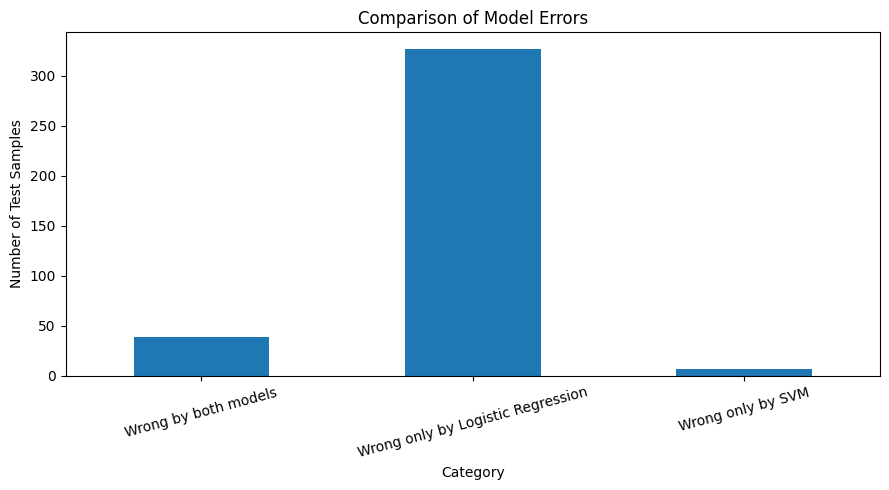

In [24]:
error_overlap_df.set_index("Category").plot(
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.ylabel("Number of Test Samples")
plt.title("Comparison of Model Errors")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [25]:
error_type_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM"
    ],
    "False Positives": [
        len(logistic_fp),
        len(svm_fp)
    ],
    "False Negatives": [
        len(logistic_fn),
        len(svm_fn)
    ]
})

error_type_df

,Model,False Positives,False Negatives
0,Logistic Regression,182,184
1,SVM,22,24


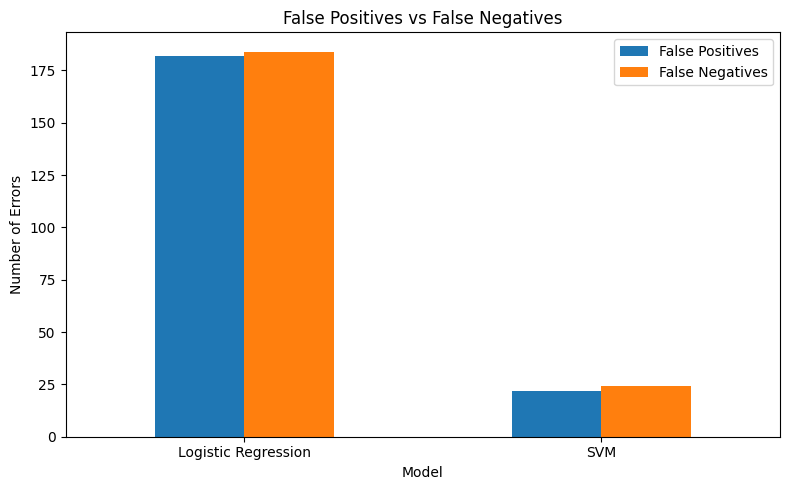

In [26]:
error_type_df.set_index("Model").plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Number of Errors")
plt.title("False Positives vs False Negatives")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
logistic_total_errors = len(logistic_errors)
svm_total_errors = len(svm_errors)

error_reduction = (
    (logistic_total_errors - svm_total_errors)
    / logistic_total_errors
) * 100

print(
    f"SVM reduced total classification errors by "
    f"{error_reduction:.2f}% compared with Logistic Regression."
)

SVM reduced total classification errors by 87.43% compared with Logistic Regression.


In [28]:
efficiency_df = pd.DataFrame([
    {
        "Model": "TF-IDF + Logistic Regression",
        "Hardware": "Local CPU",
        "Training Time (min)": np.nan,
        "Test F1": 0.993275,
        "Test Errors": 366
    },
    {
        "Model": "TF-IDF + SVM",
        "Hardware": "Local CPU",
        "Training Time (min)": np.nan,
        "Test F1": 0.999155,
        "Test Errors": 46
    },
    {
        "Model": "RoBERTa-base",
        "Hardware": "Tesla T4 GPU",
        "Training Time (min)": 165,
        "Test F1": 0.998642,
        "Test Errors": np.nan
    }
])

efficiency_df

,Model,Hardware,Training Time (min),Test F1,Test Errors
0,TF-IDF + Logistic Regression,Local CPU,NaN,0.993275,366.0
1,TF-IDF + SVM,Local CPU,NaN,0.999155,46.0
2,RoBERTa-base,Tesla T4 GPU,165.0,0.998642,NaN


In [29]:
import time

start = time.perf_counter()

_ = log_reg.predict(X_test_log)

logistic_inference_time = time.perf_counter() - start

print(
    f"Logistic Regression inference time: "
    f"{logistic_inference_time:.3f} seconds"
)

Logistic Regression inference time: 0.046 seconds


In [30]:
start = time.perf_counter()

_ = svm_model.predict(X_test_svm)

svm_inference_time = time.perf_counter() - start

print(
    f"SVM inference time: "
    f"{svm_inference_time:.3f} seconds"
)

SVM inference time: 0.050 seconds
